<a href="https://colab.research.google.com/github/EmIbrahimovic/sp26_6_4110_hw_colabs/blob/main/MP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
### Imports from HW02

import itertools
import numpy as np

class RV:
    """A random variable with a finite domain.

    Example usage:
      A = RV("A", ["x", "y", "z"])
      print(A.domain)
      print(A.dim)
      B = RV("B", [(0, 0), (0, 1), (0, 2)]))
      print(B.domain)
      print(B.dim)
    """

    def __init__(self, name, domain):
        """Initialize a RV.

        Args:
          name: str name for the RV.
          domain: list or tuple of domain values.
        """
        assert isinstance(domain, (list, tuple))
        self.name = name
        self.domain = domain
        self.dim = len(domain)

    def __hash__(self):
        return hash((self.name, tuple(self.domain)))

    def __eq__(self, other):
        return self.name == other.name and self.domain == other.domain

    def __repr__(self):
        return f"RV('{self.name}', {self.domain})"


class Potential:
    """A potential over RVs.

    Example usage:
      A = RV("varA", ["x", "y", "z"])
      B = RV("varB", [0, 1])
      table = np.array([
        [0.1, 0.0],
        [0.4, 0.9],
        [0.5, 0.1]
      ])
      potential = Potential([A, B], table)
      print(potential.rvs)
      print(potential.get(("y", 0)))
      print(potential.get_by_rvs({A: "y", B: 0}))
      print(potential.get_by_names({"varA": "y", "varB": 0}))
    """

    def __init__(self, rvs, table):
        """Create a potential from a list of RVs and a numpy array.

        The order of the random variables corresponds to the axes
        of the numpy array.

        Args:
          rvs: A list or tuple of RVs.
          array: A numpy array of potential values.

        Returns:
          potential: A Potential."""
        assert isinstance(rvs, (tuple, list))
        assert len(rvs) == len(table.shape)
        assert all(rv.dim == dim for (rv, dim) in zip(rvs, table.shape))
        assert isinstance(table, np.ndarray)
        self.rvs = rvs
        self.table = table

    def set(self, assignment, new_value):
        """Given a complete assignment and a value, update table.

        Args:
          assignment: A tuple of values in the order of self.rv.
          new_value: A new value to add to the table.

        Returns:
          value: The value in self.table.
        """
        assert len(assignment) == len(self.rvs)
        indices = [None for _ in self.rvs]
        for index, value in enumerate(assignment):
            rv = self.rvs[index]
            indices[index] = rv.domain.index(value)
        self.table[tuple(indices)] = new_value

    def get(self, assignment):
        """Given a complete assignment of values, lookup table value.

        Args:
          assignment: A tuple of values in the order of self.rv.

        Returns:
          value: The value in self.table.
        """
        assert len(assignment) == len(self.rvs)
        indices = [None for _ in self.rvs]
        for index, value in enumerate(assignment):
            rv = self.rvs[index]
            indices[index] = rv.domain.index(value)
        return self.table[tuple(indices)]

    def get_by_rvs(self, rvs_to_vals):
        """Given a complete assignment of RVs to values, lookup table value.

        Args:
          rvs_to_values: A dict from RVs to values in their domains.

        Returns:
          value: The value in self.table.
        """
        assert set(rvs_to_vals.keys()) == set(self.rvs)
        indices = [None for _ in self.rvs]
        for rv, value in rvs_to_vals.items():
            index = self.rvs.index(rv)
            indices[index] = rv.domain.index(value)
        return self.table[tuple(indices)]

    def get_by_names(self, rv_name_dict):
        """Given a dict from RV names (strs) to assignments,
        return the corresponding value in the potential table.

        Args:
          rv_name_dict: A dict from str names to values.
          potential: A Potential.

        Returns:
          value: The float value from potential.table.
        """
        assert len(rv_name_dict) == len(self.rvs)
        rv_name_to_rv = {rv.name: rv for rv in self.rvs}
        rvs_to_vals = {}
        for rv_name, value in rv_name_dict.items():
            rv = rv_name_to_rv[rv_name]
            rvs_to_vals[rv] = value
        return self.get_by_rvs(rvs_to_vals)

    def __hash__(self):
        return hash(tuple(self.rvs)) ^ hash(self.table.tobytes())

    def __eq__(self, other):
        return hash(self) == hash(other)

    def __neq__(self, other):
        return not (self == other)

    def allclose(self, other, decimals=6):
        """Check whether two potentials are (nearly) equal.
        """
        if set(self.rvs) != set(other.rvs):
            raise ValueError("Can only compare potentials with the same RVs.")
        new_idxs = [other.rvs.index(rv) for rv in self.rvs]
        trans_table2 = np.transpose(other.table, new_idxs)
        assert self.table.shape == trans_table2.shape
        return np.allclose(self.table, trans_table2)


def neighbor_dict(rvs, potentials):
    """This helper function creates a mapping.
      - For each random variable rv, neighbors[rv] is a set of potentials that involve this RV.
      - For each potential pot, neighbors[pot] is a set of random variables involved in this potential.
    """
    neighbors = {v: set() for v in rvs + potentials}
    for p in potentials:
        for v in p.rvs:
            neighbors[p].add(v)
            neighbors[v].add(p)
    return neighbors


def iter_joint_values(rvs):
    """Iterates over joint assignments for a list of RVs.

    Returns an iterator that can be used in a for loop.

    Example usage:
      for assignment in iter_joint_values(rvs):
        print(assignment)  # a tuple
        assert assignment[0] in rvs[0].domain

    Args:
      rvs: A list of RVs.

    Yields:
      assignment: A tuple of ints representing a joint
        assignment of the random variables.
    """
    domains = [rv.domain for rv in rvs]
    return itertools.product(*domains)


def get_sub_assignment(rvs, assignment, sub_rvs):
    """Given an assignment of rvs to values, get a subassignment,
    that is, a sub-tuple of the given assignment involving only
    the given sub_rvs.

    Example usage:
      x = RV("x", [0, 1])
      y = RV("y", ["a", "b"])
      z = RV("z", [3, 5])
      rvs = (x, y, z)
      assignment = (0, "b", 3)
      sub_rvs = (z, x)
      sub_assignment = get_sub_assignment(rvs, assignment, sub_rvs)
      assert sub_assignment == (3, 0)

    Args:
      rvs: A tuple or list of RVs.
      assignment: A tuple or list of values.
      sub_rvs: A tuple or list of RVs, a subset of rvs.

    Returns:
      sub_assignment: A tuple of values.
    """
    assert set(sub_rvs).issubset(set(rvs))
    sub_assignment = []
    for rv in sub_rvs:
        idx = rvs.index(rv)
        val = assignment[idx]
        sub_assignment.append(val)
    return tuple(sub_assignment)


## Part 1.1: Exact Marginalization

Question 1

#### Code from HW 2

For transparency, I hadn't written this code initally. I copied it from the answer key. I do however completely understand what it does.

In [2]:
def multiply_potentials(potentials: list[Potential]):
    """Multiply potentials together.

    Args:
      potentials: A list of Potentials.

    Returns:
      result: A new Potential.
    """
    # Obtain a union of all the random variables
    rvs = set()
    for potential in potentials:
        rvs |= set(potential.rvs)
    rvs: list[RV] = list(rvs)

    # Calculate new value for each assignment by multiplying values of sub-assignment
    table = np.empty([rv.dim for rv in rvs])
    result = Potential(rvs, table)
    for assignment in iter_joint_values(rvs):
        val = 1
        for potential in potentials:
            potential_assignment = get_sub_assignment(rvs, assignment, potential.rvs)
            val *= potential.get(potential_assignment)

        result.set(assignment, val)

    return result

In [3]:
def marginalize(potential, rvs):
    '''Create a new potential where each rv in rvs has been marginalized out.

    Args:
      potential: A Potential.
      rvs: A set of random variables in the potential to be marginalized out.

    Returns:
      new_potential: A Potential.
    '''
    # Create new rvs
    new_rvs = [v for v in potential.rvs if v not in rvs]

    # Get rv indexes
    idxs = tuple([potential.rvs.index(rv) for rv in rvs])

    # Create new table
    new_table = potential.table.sum(axis=idxs)

    # Finish potential
    return Potential(rvs=new_rvs, table=new_table)

#### New code

In [4]:
DOMAIN = ['F', 'C']

obs_to_index = {
    'F': 1,
    'C': 0
}

def get_name(r, c):
    return f"a_{r}_{c}"

In [ ]:
def obs_to_pot(obs, prior, sensor_metrics=[1, 0]):
    """
    by default, the sensor is perfect
    """
    mapping = {
        'F': np.array([1 - sensor_metrics[0], sensor_metrics[0]]),
        'C': np.array([1 - sensor_metrics[1], sensor_metrics[1]]),
        'U': np.array(prior)
    }
    return mapping[obs]

In [5]:
def _get_joint(all_rvs, observations: list[list[str]],
                pairwise_pot: np.ndarray,
                unary_pot: np.ndarray):
    n, m = len(observations), len(observations[0])
    all_potentials = []

    for r in range(n):
        for c in range(m):
            rv = all_rvs[(r, c)]
            obs = observations[r][c]

            # Define the unary potential based on the observation
            all_potentials.append(Potential([rv], obs_to_pot(obs, unary_pot)))

            # Define the binary potential between a cell and its right & below neighbors
            if r < n - 1:
                all_potentials.append(Potential([rv, all_rvs[(r + 1, c)]], pairwise_pot))
            if c < m - 1:
                all_potentials.append(Potential([rv, all_rvs[(r, c + 1)]], pairwise_pot))

    # Calculate the joint potential table
    return multiply_potentials(all_potentials)

In [6]:
def get_joint(observations: list[list[str]],
                pairwise_pot: np.ndarray,
                unary_pot: np.ndarray):

    n, m = len(observations), len(observations[0])
    all_rvs = {(r, c): RV(get_name(r, c), DOMAIN) for r in range(n) for c in range(m)}

    return _get_joint(all_rvs, observations, pairwise_pot, unary_pot)

In [7]:
def _get_marginals_from_joint(all_rvs, observations, joint_potential):
    n, m = len(observations), len(observations[0])
    all_rvs = {(r, c): RV(get_name(r, c), DOMAIN) for r in range(n) for c in range(m)}

    all_marginals = []
    for r in range(n):
        all_marginals.append([])
        for c in range(m):
            all_others = {all_rvs[key] for key in all_rvs.keys() - {(r, c)} }
            all_marginals[r].append(marginalize(joint_potential, all_others))

    return all_marginals

In [8]:
def get_marginals(observations: list[list[str]],
                      pairwise_pot: np.ndarray,
                      unary_pot: np.ndarray) -> Potential:
    """
    A  function to take in an observation grid, a pairwise potential, and a potential for the
    prior belief of fire at each cell and return the marginal probabilities of fire at each cell
    """

    n, m = len(observations), len(observations[0])
    all_rvs = {(r, c): RV(get_name(r, c), DOMAIN) for r in range(n) for c in range(m)}
    joint_potential = _get_joint(all_rvs, observations, pairwise_pot, unary_pot)
    return _get_marginals_from_joint(all_rvs, observations, joint_potential)

In [9]:
def normalize_and_fire(all_marginal_tables: list[list[float]]) -> list[list[float]]:
    """
    Takes in a 2d matrix of potentials, each representing an unnormalized probability
    distribution over the states 'C', 'F' for the given cell.

    Returns the 2d matrix of normalized probability values that a cell is fire
    """

    return [
        [
            potential[obs_to_index['F']] / potential.sum()
            for potential in potential_row
        ] for potential_row in all_marginal_tables
    ]

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def make_heatmap(data):
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(data, annot=True, fmt=".3f", cmap="coolwarm",
                vmin=0, vmax=1, xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title("Fire Probability Heat Map")
    return fig

In [11]:
pairwise_potential = [[0.7, 0.3], [0.3, 0.7]]
unary = [0.6, 0.4]

In [12]:
observations_outer = [
['F', 'F', 'U', 'U'],
['U', 'F', 'U', 'U'],
['F', 'U', 'C', 'U'],
['U', 'U', 'C', 'U']
]

In [13]:
all_marginals = get_marginals(observations_outer,
                                        np.array(pairwise_potential),
                                        np.array(unary))

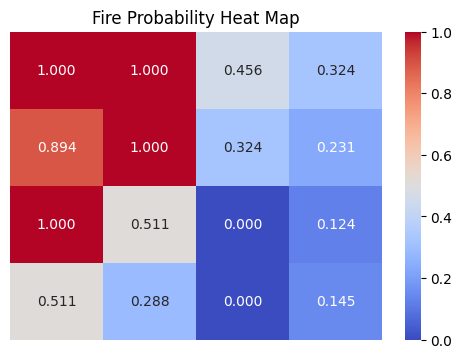

In [14]:
data = normalize_and_fire([[pot.table for pot in pot_row] for pot_row in all_marginals])
heatmap_fig = make_heatmap(data)
plt.show()

The smallest non-zero value of the potential in our table is:

In [15]:
joint_potential = get_joint(observations_outer, pairwise_potential, unary)
print(np.where(joint_potential.table == 0, 1, joint_potential.table).min())

AttributeError: 'list' object has no attribute 'shape'

On a 2x2 and 3x3 grid with all unknowns we obtain the following fire probabilities:

In [16]:
observations_outer = [
    ['U', 'U'],
    ['U', 'U']
]

# observations_outer = [
#     ['U', 'U', 'U'],
#     ['U', 'U', 'U'],
#     ['U', 'U', 'U'],
# ]


In [17]:
all_marginals = get_marginals(observations_outer,
                                        np.array(pairwise_potential),
                                        np.array(unary))

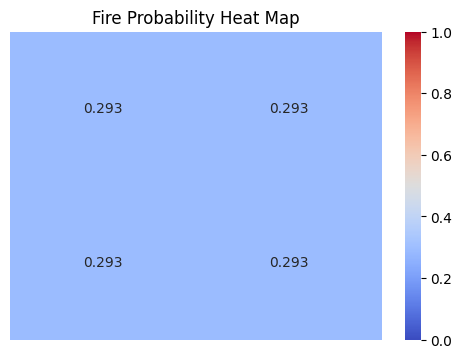

In [18]:
data = normalize_and_fire([[pot.table for pot in pot_row] for pot_row in all_marginals])
heatmap_fig = make_heatmap(data)
plt.show()

## Part 1.2: Loopy Belief Propagation

Loopy Belief Propagation implementation

In [19]:
def fire_mrf_lbp_marginals(pairwise_pot, unary_pots, max_iters=100, tol=1e-6):
    """
    Computes approximate marginals using Loopy Belief Propagation given pairwise potential
    and array of unary potentials for each cell.

    Args:
        pairwise_pot: 2x2 array [[phi(0,0), phi(0,1)], [phi(1,0), phi(1,1)]].
        unary_pots: (rows, cols, 2) array of unary potentials for each cell.
        max_iters: int for maximum number of iterations to run LBP for.
        tol: float for how much the marginal probability of fire in any cell can change by between iterations
    """
    rows, cols = unary_pots.shape[0], unary_pots.shape[1]
    # Initialize messages: (Direction, Row, Col, State)
    # 0: Messages from Up, 1: Messages from Down, 2: Messages from Left, 3: Messages from Right
    msgs = np.ones((4, rows, cols, 2))

    for i in range(max_iters):
        old_msgs = msgs.copy()

        # Compute the product of all incoming messages at each node
        # Belief(x) \propto Unary(x) * Message_Up * Message_Down * Message_Left * Message_Right
        combined = unary_pots * msgs[0] * msgs[1] * msgs[2] * msgs[3]

        # Update messages for each direction
        # 1. Update msgs[0] (From Up): Neighbor (r-1) sends to r
        # We need Belief at (r-1) excluding message from r (Down).
        cavity_for_down = combined / msgs[1]
        msgs[0, 1:, :] = np.dot(cavity_for_down[:-1, :], pairwise_pot)

        # 2. Update msgs[1] (From Down): Neighbor (r+1) sends to r
        # We need Belief at (r+1) excluding message from r (Up).
        cavity_for_up = combined / msgs[0]
        msgs[1, :-1, :] = np.dot(cavity_for_up[1:, :], pairwise_pot)

        # 3. Update msgs[2] (From Left): Neighbor (c-1) sends to c
        # We need Belief at (c-1) excluding message from c (Right).
        cavity_for_right = combined / msgs[3]
        msgs[2, :, 1:] = np.dot(cavity_for_right[:, :-1], pairwise_pot)

        # 4. Update msgs[3] (From Right): Neighbor (c+1) sends to c
        # We need Belief at (c+1) excluding message from c (Left).
        cavity_for_left = combined / msgs[2]
        msgs[3, :, :-1] = np.dot(cavity_for_left[:, 1:], pairwise_pot)

        # Normalize messages
        msgs /= np.sum(msgs, axis=-1, keepdims=True)

        # Check for convergence
        if tol and np.allclose(msgs, old_msgs, atol=tol):
            print(f"Converged at iteration {i + 1}")
            break

    # Final Beliefs
    beliefs = unary_pots * msgs[0] * msgs[1] * msgs[2] * msgs[3]
    marginals = beliefs / np.sum(beliefs, axis=-1, keepdims=True)

    return marginals

Question 5

In [20]:
def fire_mrf_lbp_conditionals(pairwise_pot, prior, observations, sensor_metrics, max_iters=1000, tol=1e-6):
    """
    Computes approximate marginal probabilities of fire using Loopy Belief Propagation
    given a grid of imperfect observations.

    Args:
        pairwise_pot: 2x2 array [[phi(0,0), phi(0,1)], [phi(1,0), phi(1,1)]].
        prior: Length 2 prior belief potential [prior(clear), prior(fire)]
        observations: 2D rows x cols array with "F", "C", or "U".
        sensor_metrics: [P(obs fire | fire), P(obs fire | clear)].
        max_iters: int for maximum number of iterations to run LBP for.
        tol: float for how much the marginal probability of fire in any cell can change by
             between iterations before it's considered converged
    """
    unary_pots = [[obs_to_pot(obs, prior, sensor_metrics) for obs in obs_row]
                        for obs_row in observations]

    return fire_mrf_lbp_marginals(np.array(pairwise_pot), np.array(unary_pots), max_iters, tol)


Evaluating for large grid:

In [21]:
pairwise_potential = [[0.7, 0.3], [0.3, 0.7]]
unary = [0.6, 0.4]
sensor_metrics = [0.8, 0.05]

In [22]:
observations_outer = [
['U', 'F', 'U', 'C', 'U', 'U', 'U'],
['U', 'F', 'F', 'U', 'C', 'U', 'C'],
['U', 'F', 'F', 'U', 'U', 'C', 'U'],
['U', 'F', 'U', 'F', 'U', 'U', 'U'],
['U', 'U', 'F', 'U', 'U', 'U', 'U'],
['F', 'F', 'U', 'U', 'F', 'U', 'U'],
['U', 'C', 'C', 'U', 'U', 'U', 'F']
]


In [23]:
def mse(t1, t2):
    t1, t2 = np.array(t1), np.array(t2)
    return ((t2 - t1)**2).mean()


marg_fires_1000 = normalize_and_fire(fire_mrf_lbp_conditionals(pairwise_potential,
                                         unary,
                                         observations_outer,
                                         sensor_metrics,
                                         max_iters=1000, tol=1e-6))

Converged at iteration 847


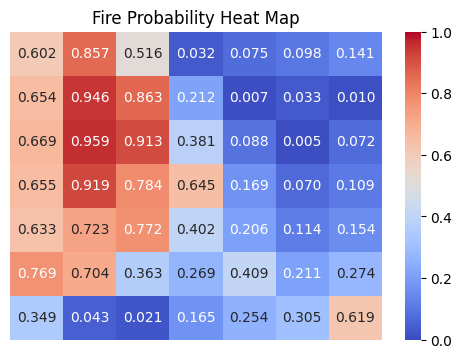

In [24]:
heatmap_fig = make_heatmap(marg_fires_1000)
plt.show()

Second test for the small grid:

In [25]:
small_grid = [
['F', 'F', 'U', 'U'],
['U', 'F', 'U', 'U'],
['F', 'U', 'C', 'U'],
['U', 'U', 'C', 'U']
]

blank_grid = [
    ['U', 'U', 'U'],
    ['U', 'U', 'U'],
    ['U', 'U', 'U'],
]

sensor_metrics_exact = [1, 0]

In [26]:
marginal_pots_small_exact = get_marginals(small_grid,
                                        np.array(pairwise_potential),
                                        np.array(unary))

marginals_small_exact = normalize_and_fire([pot.table for pot in pot_row] for pot_row in marginal_pots_small_exact)

The approximate grid is: 
 [[np.float64(1.0), np.float64(1.0), np.float64(0.45614949353041484), np.float64(0.3238195826658918)], [np.float64(0.894393741851369), np.float64(1.0), np.float64(0.3238195826658912), np.float64(0.23110430530558382)], [np.float64(1.0), np.float64(0.5106755821996771), np.float64(0.0), np.float64(0.12442240160700173)], [np.float64(0.5106755821996771), np.float64(0.28821766197832555), np.float64(0.0), np.float64(0.14528651683112784)]]


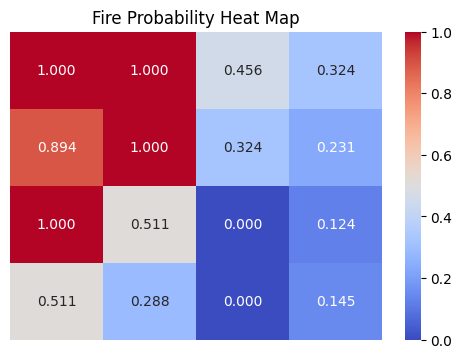

In [27]:
print(f"The approximate grid is: \n {marginals_small_exact}")
heatmap_fig = make_heatmap(marginals_small_exact)
plt.show()

In [28]:
marginal_pots_small_apprx = fire_mrf_lbp_conditionals(pairwise_potential,
                                         unary,
                                         small_grid,
                                         sensor_metrics_exact,
                                         max_iters=500, tol=1e-6)

marginals_small_apprx = normalize_and_fire(marginal_pots_small_apprx)

Converged at iteration 22


The approximate grid is: 
 [[np.float64(1.0), np.float64(1.0), np.float64(0.45464842181629983), np.float64(0.31780068351695295)], [np.float64(0.894393741851369), np.float64(1.0), np.float64(0.31780068351695295), np.float64(0.22191449965176094)], [np.float64(1.0), np.float64(0.5106755821996772), np.float64(0.0), np.float64(0.12234993800839368)], [np.float64(0.5106755821996772), np.float64(0.288217661978326), np.float64(0.0), np.float64(0.14468338383664878)]]


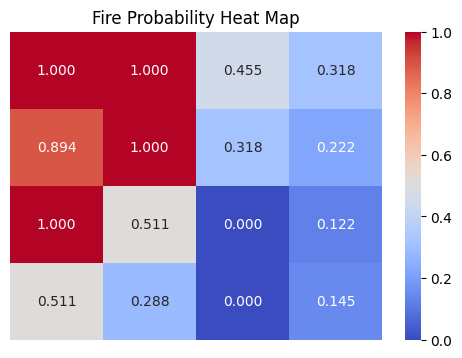

In [29]:
print(f"The approximate grid is: \n {marginals_small_apprx}")
heatmap_fig = make_heatmap(marginals_small_apprx)
plt.show()

In [30]:
mse_small = mse(marginals_small_exact, marginals_small_apprx)
print(f"The mean squared error between the exact and approximate grids is {mse_small}")

The mean squared error between the exact and approximate grids is 1.023868205954514e-05


In [ ]:
import timeit

grid_sizes = [3, 4, 5]

for gs in grid_sizes:
    grid = [['U'] * gs for _ in range(gs)]

    time_exact = timeit.timeit(lambda: get_marginals(grid, np.array(pairwise_potential), np.array(unary)), number=10)
    time_apprx = timeit.timeit(lambda: fire_mrf_lbp_conditionals(pairwise_potential, unary, grid, sensor_metrics_exact), number=10)

    print(f"To calculate the exact grid of size {gs} we needed: {time_exact/10} s")
    print(f"To calculate the approximate grid of size {gs} we needed: {time_apprx/10} s")

Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
Converged at iteration 24
To calculate the exact grid of size 3 we needed: 0.05001526050000109 s
To calculate the approximate grid of size 3 we needed: 0.0014778475000014168 s
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
Converged at iteration 20
To calculate the exact grid of size 4 we needed: 18.786750059800003 s
To calculate the approximate grid of size 4 we needed: 0.0012720633999947495 s


## Part 1.3: Gibbs Sampling

Question 9

In [ ]:
def fire_mrf_gibbs_conditionals(pairwise_pot, prior, observations, sensor_metrics, num_samples=5000, burn_in=1000):
    """
    Estimates marginal probabilities of fire using Gibbs Sampling.

    Args:
        pairwise_pot: 2x2 array [[phi(0,0), phi(0,1)], [phi(1,0), phi(1,1)]].
        prior: Float prior for fire in a cell.
        observations: 2D rows x cols array with "F", "C", or "U".
        sensor_metrics: [P(obs fire | fire), P(obs fire | clear)]
        num_samples: Total number of iterations to collect.
        burn_in: Number of initial samples to discard
    """

    n, m = len(observations), len(observations[0])
    rng = np.random.default_rng()

    board = [[rng.choice(['C', 'F'], p=obs_to_pot(observations[r][c], [1 - prior, prior], sensor_metrics))
            for c in range(m)]
            for r in range(n)
    ]

    fire_cnts = [[int(board[r][c] == 'F') for c in range(m)] for r in range(n)]


    for iter_num in range(num_samples + burn_in):
        ri = rng.integers(n)
        ci = rng.integers(m)
        obs = observations[ri][ci]
        rv = RV(get_name(ri, ci), DOMAIN)

        # The prior on an unobserved node (despite the fact that it has an assignment right now)
        potentials = [Potential([rv], obs_to_pot(obs, [1 - prior, prior], sensor_metrics))]
        neighbor_rvs = {}
        for dr, dc in [(-1, 0), (1, 0), (0, 1), (0, -1)]:
            r_n = ri + dr
            c_n = ci + dc
            if not (0 <= r_n < n and 0 <= c_n < m):
                continue

            rv_n = RV(get_name(r_n, c_n), DOMAIN)
            neighbor_rvs.add(rv_n)
            obs_n = board[r_n][ri + dc]

            # Append binary potential
            potentials.append(
                Potential([rv, rv_n], np.array(pairwise_pot))
            )
            # Append unary potential of the neighbor based on current assignment
            potentials.append(
                Potential([rv_n], obs_to_pot(obs_n, [1 - prior, prior], sensor_metrics))
            )

        # Calculate the conditional potential
        joint_potential = multiply_potentials(potentials)
        conditional_potential = marginalize(joint_potential, neighbor_rvs)

        new_assignment = np.random.random_choice(['C', 'F'], p=conditional_potential.table)
        board[ri][ci] = new_assignment

In [ ]:
#